Market Basket Analysis with Python - Snapdeal

Project Video Link:- https://youtu.be/FHVIFFgDS1Q

Project Link:- https://colab.research.google.com/drive/1t95HK5bsx4-s1vD0mIXuQZ0GktoP2zQT?usp=sharing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk


In [4]:
SnapDeal=pd.read_csv(r"D:\Internshala Projects\Project 5\SnapDeal.csv")

In [13]:
SnapDeal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   651 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [14]:
SnapDeal.shape

(800, 24)

In [20]:
SnapDeal.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [128]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Timestamp', 'Age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'Transaction', 'Purchase_Frequency_Score']


In [24]:
SnapDeal.duplicated().sum()

0

In [26]:
SnapDeal.isnull().sum()

Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                    149
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            0
Shopping_Satisfaction                      0
Service_Appreciation                       0
Improvemen

In [33]:
SnapDeal.notnull().sum()

Timestamp                                800
age                                      800
Gender                                   800
Purchase_Frequency                       800
Purchase_Categories                      800
Personalized_Recommendation_Frequency    800
Browsing_Frequency                       800
Product_Search_Method                    800
Search_Result_Exploration                800
Customer_Reviews_Importance              800
Add_to_Cart_Browsing                     800
Cart_Completion_Frequency                800
Cart_Abandonment_Factors                 800
Saveforlater_Frequency                   800
Review_Left                              800
Review_Reliability                       800
Review_Helpfulness                       800
Personalized_Recommendation_Frequency    800
Recommendation_Helpfulness               800
Rating_Accuracy                          800
Shopping_Satisfaction                    800
Service_Appreciation                     800
Improvemen

In [37]:
# Replaced missing values in Product_Search_Method with "Others"
# Handle Missing Values
SnapDeal["Product_Search_Method"] = (SnapDeal["Product_Search_Method"].replace(["", " ", "NA", "N/A"], np.nan).fillna("Others"))

In [38]:
SnapDeal.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [39]:
SnapDeal.isnull().sum()

Timestamp                                0
age                                      0
Gender                                   0
Purchase_Frequency                       0
Purchase_Categories                      0
Personalized_Recommendation_Frequency    0
Browsing_Frequency                       0
Product_Search_Method                    0
Search_Result_Exploration                0
Customer_Reviews_Importance              0
Add_to_Cart_Browsing                     0
Cart_Completion_Frequency                0
Cart_Abandonment_Factors                 0
Saveforlater_Frequency                   0
Review_Left                              0
Review_Reliability                       0
Review_Helpfulness                       0
Personalized_Recommendation_Frequency    0
Recommendation_Helpfulness               0
Rating_Accuracy                          0
Shopping_Satisfaction                    0
Service_Appreciation                     0
Improvement_Areas                        0
transaction

In [40]:
SnapDeal["Timestamp"] = pd.to_datetime(SnapDeal["Timestamp"], errors="coerce")

C:\Users\user\AppData\Local\Temp\ipykernel_18696\3931891890.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  SnapDeal["Timestamp"] = pd.to_datetime(SnapDeal["Timestamp"], errors="coerce")


In [46]:
SnapDeal.dtypes

Timestamp                                datetime64[ns, UTC-05:30]
age                                                          int64
Gender                                                      object
Purchase_Frequency                                          object
Purchase_Categories                                         object
Personalized_Recommendation_Frequency                       object
Browsing_Frequency                                          object
Product_Search_Method                                       object
Search_Result_Exploration                                   object
Customer_Reviews_Importance                                  int64
Add_to_Cart_Browsing                                        object
Cart_Completion_Frequency                                   object
Cart_Abandonment_Factors                                    object
Saveforlater_Frequency                                      object
Review_Left                                                 ob

In [12]:
SnapDeal.shape

(800, 24)

In [101]:
SnapDeal.rename(columns={"age": "Age"}, inplace=True)
SnapDeal.rename(columns={"transaction":"Transaction"},inplace=True)

In [102]:
SnapDeal.to_csv("SnapDeal_Cleaned.csv",index=False)

In [6]:
print("Cleaned dataset saved as 'SnapDeal_Cleaned.csv'")

Cleaned dataset saved as 'SnapDeal_Cleaned.csv'


In [103]:
df=pd.read_csv('SnapDeal_Cleaned.csv')

In [104]:
df.head()

,Timestamp,Age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,Transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [71]:
df.shape

(800, 24)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Timestamp                                800 non-null    object
 1   Age                                      800 non-null    int64 
 2   Gender                                   800 non-null    object
 3   Purchase_Frequency                       800 non-null    object
 4   Purchase_Categories                      800 non-null    object
 5   Personalized_Recommendation_Frequency    800 non-null    object
 6   Browsing_Frequency                       800 non-null    object
 7   Product_Search_Method                    800 non-null    object
 8   Search_Result_Exploration                800 non-null    object
 9   Customer_Reviews_Importance              800 non-null    int64 
 10  Add_to_Cart_Browsing                     800 non-null    objec

In [115]:
df.notnull().sum()

Timestamp                                  800
Age                                        800
Gender                                     800
Purchase_Frequency                         800
Purchase_Categories                        800
Personalized_Recommendation_Frequency      800
Browsing_Frequency                         800
Product_Search_Method                      800
Search_Result_Exploration                  800
Customer_Reviews_Importance                800
Add_to_Cart_Browsing                       800
Cart_Completion_Frequency                  800
Cart_Abandonment_Factors                   800
Saveforlater_Frequency                     800
Review_Left                                800
Review_Reliability                         800
Review_Helpfulness                         800
Personalized_Recommendation_Frequency.1    800
Recommendation_Helpfulness                 800
Rating_Accuracy                            800
Shopping_Satisfaction                      800
Service_Appre

In [88]:
df["Gender"]

0                 Others
1                 Female
2      Prefer Not To Say
3                 Others
4                 Female
             ...        
795                 Male
796               Female
797               Female
798                 Male
799               Others
Name: Gender, Length: 800, dtype: object

In [89]:
df["Customer_Reviews_Importance"]

0      4
1      1
2      2
3      2
4      5
      ..
795    5
796    3
797    5
798    2
799    2
Name: Customer_Reviews_Importance, Length: 800, dtype: int64

In [117]:
df["Age"]

0      59
1      48
2      57
3      30
4      51
       ..
795    60
796    56
797    48
798    40
799    67
Name: Age, Length: 800, dtype: int64

In [91]:
df["Shopping_Satisfaction"]

0      3
1      2
2      3
3      5
4      1
      ..
795    2
796    4
797    4
798    3
799    2
Name: Shopping_Satisfaction, Length: 800, dtype: int64

In [ ]:
#Removed the duplicates or inconsistent survey responses.
#Standardize categorical/numerical entries.
#Handle missing values and inconsistent formats in Product_Search_Method and other fields.
#Rename duplicate or misformatted columns.
#Convert numerical rating columns and checked the datatypes.

In [ ]:
#Task 2-#Summarize customer demographics (age, gender distribution).

In [118]:
df["Age"].describe()

count    800.000000
mean      36.053750
std       19.310087
min        3.000000
25%       18.000000
50%       37.000000
75%       53.000000
max       67.000000
Name: Age, dtype: float64

In [119]:
df["Gender"].describe()

count      800
unique       4
top       Male
freq       213
Name: Gender, dtype: object

In [ ]:
#Analyze overall purchase frequency and most popular product categories.

In [120]:
df["Purchase_Frequency"].value_counts()

Purchase_Frequency
Multiple times a week     166
Once a month              164
Once a week               161
Few times a month         157
Less than once a month    152
Name: count, dtype: int64

In [122]:
df["Purchase_Categories"].value_counts()

Purchase_Categories
Clothing and Fashion                                                                                36
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion                            34
Clothing and Fashion;Home and Kitchen                                                               34
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen           32
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others    32
Clothing and Fashion;others                                                                         32
Beauty and Personal Care;Clothing and Fashion;others                                                32
others                                                                                              32
Groceries and Gourmet Food;Beauty and Personal Care;Home and Kitchen                                32
Beauty and Personal Care;Clothing and Fashion;Home an

In [ ]:
#most popular product categories are Clothing and fashion.

In [ ]:
#Identify top browsing methods and most common cart abandonment factors.

In [129]:
df["Product_Search_Method"].value_counts()

Product_Search_Method
others        182
Keyword       163
categories    156
Filter        150
Others        149
Name: count, dtype: int64

In [124]:
df["Cart_Abandonment_Factors"].value_counts()

Cart_Abandonment_Factors
Found a better price elsewhere                219
others                                        196
High shipping costs                           194
Changed my mind or no longer need the item    191
Name: count, dtype: int64

In [ ]:
#Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

In [130]:
df["Shopping_Satisfaction"].mean()

2.98875

In [133]:
df["Shopping_Satisfaction"].median()

3.0

In [136]:
df["Rating_Accuracy"].mean()

2.96375

In [137]:
df["Rating_Accuracy"].median()

3.0

In [ ]:
#Generate summary statistics and visualizations for key behavioral variables.

In [140]:
behavior_columns = [
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy"
]

# Summary statistics

df[behavior_columns].describe()

,Shopping_Satisfaction,Customer_Reviews_Importance,Rating_Accuracy
count,800.000000,800.000000,800.00000
mean,2.988750,2.988750,2.96375
std,1.407515,1.400384,1.42565
min,1.000000,1.000000,1.00000
25%,2.000000,2.000000,2.00000
50%,3.000000,3.000000,3.00000
75%,4.000000,4.000000,4.00000
max,5.000000,5.000000,5.00000


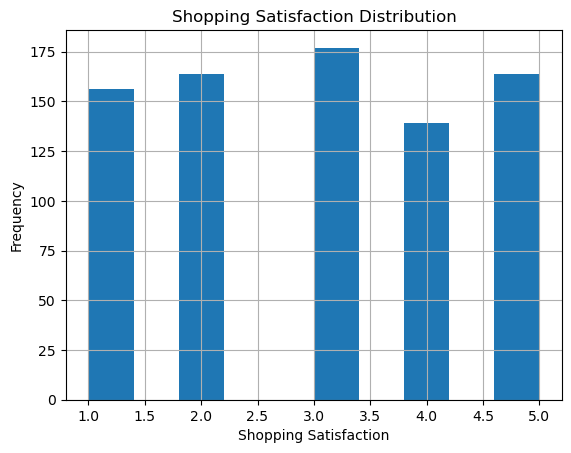

In [142]:
df["Shopping_Satisfaction"].hist(bins=10)

plt.title("Shopping Satisfaction Distribution")
plt.xlabel("Shopping Satisfaction")
plt.ylabel("Frequency")

plt.show()

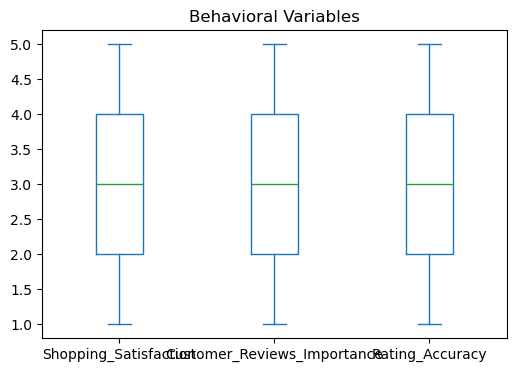

In [144]:
df[behavior_columns].plot(kind="box", figsize=(6,4))

plt.title("Behavioral Variables")

plt.show()

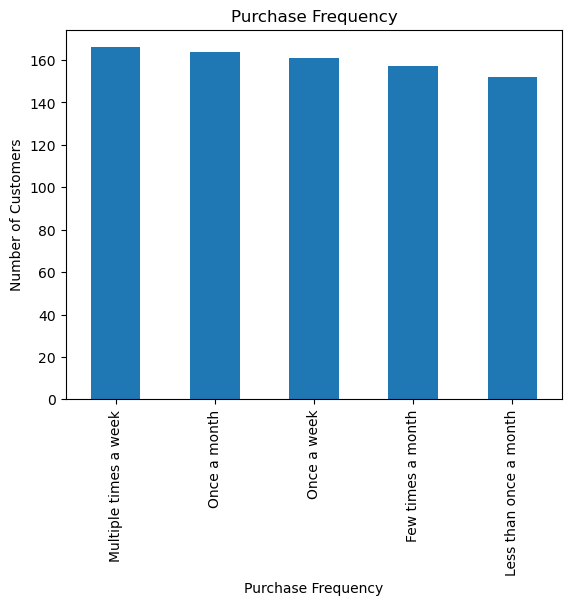

In [145]:
df["Purchase_Frequency"].value_counts().plot(
    kind="bar"
)

plt.title("Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")

plt.show()

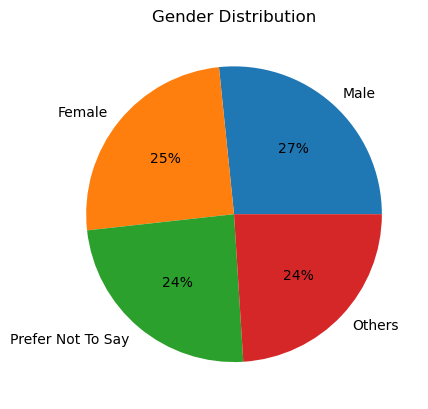

In [151]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.0f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

In [153]:
#Task 3: Customer Segmentation and Profiling (20 Marks)
#● Segment customers based on purchase frequency and shopping satisfaction levels.
#● Create profiles such as:
#○ Frequent Buyers: High purchase frequency, high satisfaction.
#○ Occasional Shoppers: Medium frequency, moderate satisfaction.
#○ At-Risk Customers: Low satisfaction or frequent cart abandonment.

#● Analyze demographic or behavioral differences across these segments.
#● Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.

In [16]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [17]:
df["Purchase_Frequency"]

0                 Once a week
1                Once a month
2       Multiple times a week
3           Few times a month
4                Once a month
                ...          
795    Less than once a month
796     Multiple times a week
797     Multiple times a week
798     Multiple times a week
799     Multiple times a week
Name: Purchase_Frequency, Length: 800, dtype: object

In [19]:
df.groupby("Purchase_Frequency").size()

Purchase_Frequency
Few times a month         157
Less than once a month    152
Multiple times a week     166
Once a month              164
Once a week               161
dtype: int64

In [27]:
def customer_segment(row):

    if row["Purchase_Frequency"] in ["Once a week", "Multiple times a week"] and row["Shopping_Satisfaction"] >= 4:
        return "Frequent Buyers"

    elif row["Purchase_Frequency"] in ["Few times a month", "Once a month"] and row["Shopping_Satisfaction"] >= 3:
        return "Occasional Shoppers"

    elif row["Purchase_Frequency"] == "Less than once a month" or row["Shopping_Satisfaction"] <= 2:
        return "At-Risk Customers"

    else:
        return "Other"

df["Customer_Segment"] = df.apply(customer_segment, axis=1)


In [32]:
segment_counts = df["Customer_Segment"].value_counts()

print(segment_counts)

Customer_Segment
At-Risk Customers      421
Occasional Shoppers    183
Frequent Buyers        128
Other                   68
Name: count, dtype: int64


In [45]:
grouped = df.groupby("Purchase_Frequency")
for frequency, group in grouped:
   display(group)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Segment
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686,Occasional Shoppers
14,2023/06/09 8:10:05 AM GMT+5:30,15,Female,Few times a month,Beauty and Personal Care;Clothing and Fashion,Sometimes,Few times a week,categories,First page,4,...,Never,Sometimes,3,No,4,5,Customer service,I have no problem with Amazon yet. But others ...,397056,Occasional Shoppers
24,2023/06/09 10:23:05 AM GMT+5:30,54,Male,Few times a month,Home and Kitchen;others,Yes,Few times a month,Keyword,First page,1,...,Moderately,No,2,Sometimes,4,4,.,.,738929,Occasional Shoppers
28,2023/06/08 8:26:58 PM GMT+5:30,20,Female,Few times a month,Clothing and Fashion;Home and Kitchen;others,Sometimes,Few times a month,NaN,Multiple pages,1,...,Occasionally,No,5,Sometimes,5,3,Customer service,UI,742772,Occasional Shoppers
42,2023/06/08 10:24:19 PM GMT+5:30,48,Male,Few times a month,Beauty and Personal Care;others,No,Rarely,Keyword,Multiple pages,1,...,Rarely,Yes,4,Sometimes,2,1,Wide product selection,No problems with Amazon,922302,At-Risk Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,2023/06/08 5:07:35 PM GMT+5:30,55,Prefer not to say,Few times a month,Beauty and Personal Care;Clothing and Fashion,No,Few times a month,Keyword,First page,1,...,Rarely,Sometimes,4,No,5,1,Competitive prices,Quality of product is very poor according to t...,850593,At-Risk Customers
777,2023/06/08 5:43:45 PM GMT+5:30,40,Others,Few times a month,Clothing and Fashion;Home and Kitchen,Yes,Rarely,others,First page,2,...,Never,Sometimes,5,Yes,5,2,Competitive prices,Reducing packaging waste,880702,At-Risk Customers
781,2023/06/09 10:28:57 AM GMT+5:30,8,Others,Few times a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,3,...,Never,No,3,No,5,1,Customer service,I don't have any problem with Amazon,708679,At-Risk Customers
785,2023/06/05 12:05:20 AM GMT+5:30,60,Female,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,others,Multiple pages,5,...,Moderately,No,1,No,2,3,Competitive prices,Nil,190661,Occasional Shoppers


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Segment
10,2023/06/07 10:10:58 PM GMT+5:30,28,Others,Less than once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Multiple times a day,Keyword,First page,5,...,Rarely,Sometimes,5,Sometimes,4,4,Customer service,Customer service responsiveness,797322,At-Risk Customers
18,2023/06/09 2:51:07 PM GMT+5:30,51,Prefer not to say,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,First page,5,...,Rarely,No,1,Sometimes,3,3,Quick delivery,I don't have any problem with Amazon,119213,At-Risk Customers
20,2023/06/08 3:23:58 AM GMT+5:30,28,Male,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,categories,First page,3,...,Rarely,Yes,1,No,2,4,All the above,Customer service responsiveness,133335,At-Risk Customers
21,2023/06/06 8:56:17 PM GMT+5:30,10,Prefer not to say,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,others,Multiple pages,5,...,Never,Sometimes,2,Sometimes,5,2,Customer service,Shipping speed and reliability,886529,At-Risk Customers
22,2023/06/11 11:15:03 PM GMT+5:30,11,Female,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,5,...,Moderately,No,5,No,4,4,.,I don't have any problem with Amazon,362553,At-Risk Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,2023/06/06 7:18:01 PM GMT+5:30,17,Male,Less than once a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,NaN,Multiple pages,1,...,Rarely,Sometimes,1,Sometimes,5,3,Wide product selection,Scrolling option would be much better than goi...,890872,At-Risk Customers
782,2023/06/08 9:40:24 PM GMT+5:30,51,Prefer not to say,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,Yes,Few times a week,Keyword,Multiple pages,4,...,Occasionally,No,3,Sometimes,3,3,Customer service,User interface of app,751973,At-Risk Customers
789,2023/06/08 3:29:26 AM GMT+5:30,47,Female,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,NaN,First page,5,...,Heavily,Sometimes,2,No,4,4,User-friendly website/app interface,I don't have any problem with Amazon,421355,At-Risk Customers
793,2023/06/09 9:37:44 AM GMT+5:30,4,Male,Less than once a month,Clothing and Fashion;Home and Kitchen;others,Sometimes,Few times a week,others,Multiple pages,2,...,Moderately,No,5,Yes,1,3,User-friendly website/app interface,Reducing packaging waste,537502,At-Risk Customers


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Segment
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350,Other
5,2023/06/04 11:27:53 PM GMT+5:30,33,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,Yes,Few times a month,categories,Multiple pages,3,...,Occasionally,Sometimes,5,Sometimes,4,4,Customer service,Customer service responsiveness,116480,Frequent Buyers
12,2023/06/09 9:33:35 AM GMT+5:30,7,Others,Multiple times a week,others,Sometimes,Multiple times a day,NaN,First page,3,...,Rarely,Sometimes,5,Yes,5,5,Quick delivery,Shipping speed and reliability,785442,Frequent Buyers
13,2023/06/08 5:15:27 PM GMT+5:30,48,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,Yes,Few times a week,others,First page,5,...,Heavily,Sometimes,3,Sometimes,5,5,Competitive prices,Nothing,769031,Frequent Buyers
19,2023/06/08 5:35:01 PM GMT+5:30,56,Male,Multiple times a week,Clothing and Fashion;Home and Kitchen;others,Sometimes,Few times a week,Keyword,Multiple pages,3,...,Moderately,No,3,Sometimes,3,3,.,No problems with Amazon,774345,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,2023/06/07 12:13:39 PM GMT+5:30,19,Male,Multiple times a week,Groceries and Gourmet Food;Clothing and Fashio...,Sometimes,Few times a month,Keyword,Multiple pages,3,...,Moderately,Sometimes,4,Sometimes,4,1,Competitive prices,Add more familiar brands to the list,312813,At-Risk Customers
796,2023/06/09 7:22:11 PM GMT+5:30,56,Female,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,Yes,Rarely,NaN,Multiple pages,3,...,Occasionally,Yes,4,Sometimes,4,4,Customer service,.,524319,Frequent Buyers
797,2023/06/12 3:47:01 PM GMT+5:30,48,Female,Multiple times a week,Groceries and Gourmet Food,Sometimes,Multiple times a day,others,Multiple pages,5,...,Heavily,Yes,5,Yes,2,4,Wide product selection,Product quality and accuracy,637762,Frequent Buyers
798,2023/06/06 6:51:13 PM GMT+5:30,40,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,Multiple pages,2,...,Occasionally,No,4,Sometimes,4,3,Quick delivery,Nil,290410,Other


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Segment
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,Never,Sometimes,1,No,5,2,.,.,735054,At-Risk Customers
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184,At-Risk Customers
6,2023/06/06 7:40:53 PM GMT+5:30,10,Male,Once a month,Groceries and Gourmet Food;Clothing and Fashio...,Sometimes,Few times a week,NaN,Multiple pages,5,...,Rarely,Sometimes,1,Yes,3,2,Wide product selection,Nil,445746,At-Risk Customers
8,2023/06/08 9:39:55 PM GMT+5:30,8,Female,Once a month,Clothing and Fashion,Sometimes,Few times a week,Filter,First page,3,...,Never,Yes,5,Sometimes,1,2,All the above,No problems with Amazon,571022,At-Risk Customers
11,2023/06/09 9:35:57 AM GMT+5:30,15,Others,Once a month,Clothing and Fashion;Home and Kitchen,Yes,Few times a month,NaN,First page,3,...,Never,No,4,Yes,5,3,User-friendly website/app interface,better app interface and lower shipping charges,252740,Occasional Shoppers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,2023/06/07 6:30:43 PM GMT+5:30,16,Prefer not to say,Once a month,Groceries and Gourmet Food,Yes,Few times a week,NaN,Multiple pages,2,...,Never,No,5,Yes,2,2,Customer service,I have no problem with Amazon yet. But others ...,834597,At-Risk Customers
784,2023/06/04 6:31:41 PM GMT+5:30,29,Male,Once a month,Clothing and Fashion;Home and Kitchen,Yes,Rarely,Filter,First page,1,...,Heavily,Yes,5,No,5,2,User-friendly website/app interface,Add more familiar brands to the list,299929,At-Risk Customers
787,2023/06/07 9:32:38 AM GMT+5:30,43,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a week,Filter,Multiple pages,1,...,Heavily,Yes,2,No,4,2,Customer service,User interface,668260,At-Risk Customers
790,2023/06/06 7:10:14 PM GMT+5:30,46,Others,Once a month,Groceries and Gourmet Food;Home and Kitchen;ot...,Sometimes,Multiple times a day,Keyword,First page,5,...,Moderately,Sometimes,3,No,4,1,All the above,Irrelevant product suggestions,720260,At-Risk Customers


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Segment
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348,Other
7,2023/06/06 5:16:58 PM GMT+5:30,30,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,categories,First page,2,...,Occasionally,Sometimes,1,Sometimes,5,2,Wide product selection,No problems with Amazon,372797,At-Risk Customers
9,2023/06/11 11:10:14 PM GMT+5:30,11,Female,Once a week,Clothing and Fashion,Yes,Few times a month,categories,Multiple pages,3,...,Heavily,No,3,No,2,3,Customer service,Irrelevant product suggestions,952835,Other
15,2023/06/07 11:41:56 AM GMT+5:30,58,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashio...,No,Rarely,categories,Multiple pages,4,...,Rarely,Sometimes,3,No,4,2,Product recommendations,Shipping speed and reliability,757928,At-Risk Customers
17,2023/06/04 8:00:11 PM GMT+5:30,60,Others,Once a week,Clothing and Fashion;Home and Kitchen;others,No,Few times a week,others,First page,4,...,Never,No,4,Sometimes,3,4,Customer service,I have no problem with Amazon yet. But others ...,701440,Frequent Buyers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728,2023/06/08 3:24:37 AM GMT+5:30,28,Prefer not to say,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Yes,Rarely,categories,First page,3,...,Occasionally,No,5,No,5,2,Product recommendations,Shipping speed and reliability,745511,At-Risk Customers
759,2023/06/07 9:18:55 PM GMT+5:30,63,Prefer not to say,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Filter,First page,5,...,Heavily,No,2,No,2,5,Competitive prices,Reducing packaging waste,565915,Frequent Buyers
767,2023/06/07 11:41:56 AM GMT+5:30,51,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,5,...,Never,Sometimes,1,Yes,3,1,Customer service,No problems with Amazon,818624,At-Risk Customers
770,2023/06/07 1:25:26 PM GMT+5:30,40,Prefer not to say,Once a week,Groceries and Gourmet Food;Home and Kitchen,Yes,Multiple times a day,NaN,Multiple pages,4,...,Moderately,Sometimes,4,Yes,3,2,Wide product selection,User interface of app,837191,At-Risk Customers


In [ ]:
#Above value is Customer segmentation, based on the purchase frequency.

In [ ]:
#profiles such as:
#○ Frequent Buyers: High purchase frequency, high satisfaction.
#○ Occasional Shoppers: Medium frequency, moderate satisfaction.
#○ At-Risk Customers: Low satisfaction or frequent cart abandonment.

In [48]:
def customer_profile(row):

    # Frequent Buyers
    if (row["Purchase_Frequency"] in ["Multiple times a week", "Once a week"] and
        row["Shopping_Satisfaction"] >= 4):
        return "Frequent Buyers"

    # Occasional Shoppers
    elif (row["Purchase_Frequency"] in ["Few times a month", "Once a month"] and
          row["Shopping_Satisfaction"] >= 3):
        return "Occasional Shoppers"

    # At-Risk Customers
    elif (row["Shopping_Satisfaction"] <= 2 or
          row["Cart_Abandonment_Factors"] != "None"):
        return "At-Risk Customers"

    else:
        return "Other"

df["Customer_Profile"] = df.apply(customer_profile, axis=1)

In [49]:
df["Customer_Profile"].value_counts()

Customer_Profile
At-Risk Customers      489
Occasional Shoppers    183
Frequent Buyers        128
Name: count, dtype: int64

In [ ]:
#Frequent Buyers: High purchase frequency, high satisfaction.=128
#Occasional Shoppers: Medium frequency, moderate satisfaction.=183
#At-Risk Customers: Low satisfaction or frequent cart abandonment.=489

In [ ]:
#Analyze demographic or behavioral differences across these segments.

In [54]:
#Demographic analysis across Gender.
gender_profile = pd.crosstab(df["Customer_Profile"], df["Gender"])
gender_profile

Gender,Female,Male,Others,Prefer not to say
Customer_Profile,,,,
At-Risk Customers,126,124,115,124
Frequent Buyers,27,36,35,30
Occasional Shoppers,48,53,42,40


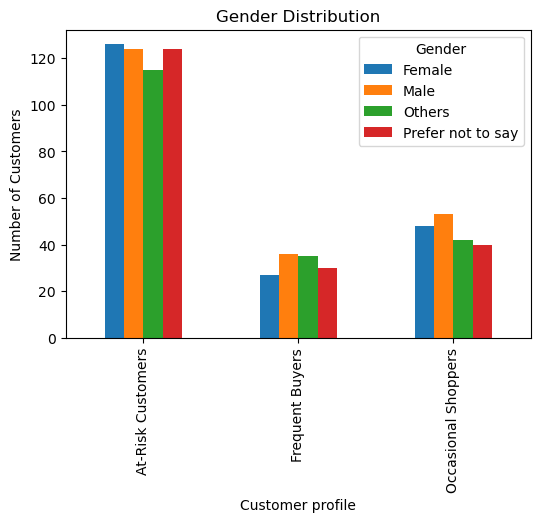

In [63]:
gender_profile.plot(kind="bar", figsize=(6,4))
plt.title("Gender Distribution")
plt.xlabel("Customer profile")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
#Behavioral Analysis

In [64]:
df.groupby("Customer_Profile")["Shopping_Satisfaction"].mean()

Customer_Profile
At-Risk Customers      2.226994
Frequent Buyers        4.562500
Occasional Shoppers    3.923497
Name: Shopping_Satisfaction, dtype: float64

In [65]:
pd.crosstab(df["Customer_Profile"], df["Purchase_Frequency"])

Purchase_Frequency,Few times a month,Less than once a month,Multiple times a week,Once a month,Once a week
Customer_Profile,,,,,
At-Risk Customers,67,152,104,71,95
Frequent Buyers,0,0,62,0,66
Occasional Shoppers,90,0,0,93,0


In [68]:
pd.crosstab(
    df["Customer_Profile"],
    df["Cart_Abandonment_Factors"]
)

Cart_Abandonment_Factors,Changed my mind or no longer need the item,Found a better price elsewhere,High shipping costs,others
Customer_Profile,,,,
At-Risk Customers,119,135,108,127
Frequent Buyers,33,39,38,18
Occasional Shoppers,39,45,48,51


In [ ]:
#Above Behavioral Analysis on the basis of Shopping_Satisfaction,Purchase_Frequency,Cart_Abandonment_Factors.

In [86]:
#Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.
df.head(3)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Customer_Segment,Customer_Profile,Purchase_Frequency_Score
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,1,NaN,3,3,Customer service,User interface of app,433348,Other,At-Risk Customers,4
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,1,NaN,5,2,.,.,735054,At-Risk Customers,At-Risk Customers,2
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,5,NaN,3,3,Customer service,Product quality and accuracy,119350,Other,At-Risk Customers,5


In [319]:
import pandas as pd
df=pd.read_csv('SnapDeal_Cleaned.csv')


In [321]:
frequency= {
    "Less than once a month": 1,
    "Once a month": 2,
    "Few times a month": 3,
    "Once a week": 4,
    "Multiple times a week": 5
}

df["Purchase_Frequency_Score"] = df["Purchase_Frequency"].map(frequency)

In [322]:
df.groupby("Recommendation_Helpfulness").size()

Recommendation_Helpfulness
No           295
Sometimes    244
Yes          261
dtype: int64

In [323]:
#Covert to the numerical value and assigned the value.
df["Recommendation_Helpfulness"] = df["Recommendation_Helpfulness"].map({
    "No": 0,
    "Sometimes": 1,
    "Yes": 2
})

In [324]:
df["Recommendation_Helpfulness"]

0      2
1      0
2      1
3      1
4      2
      ..
795    1
796    1
797    2
798    1
799    1
Name: Recommendation_Helpfulness, Length: 800, dtype: int64

In [325]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Timestamp', 'Age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'Transaction', 'Purchase_Frequency_Score']


In [326]:
X= df[
    [
        "Purchase_Frequency_Score",
        "Shopping_Satisfaction",
        "Recommendation_Helpfulness",
        "Rating_Accuracy"
    ]
]

In [327]:
X.head()

,Purchase_Frequency_Score,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
0,4,3,2,3
1,2,2,0,5
2,5,3,1,3
3,3,5,1,4
4,2,1,2,3


In [328]:
X.dtypes

Purchase_Frequency_Score      int64
Shopping_Satisfaction         int64
Recommendation_Helpfulness    int64
Rating_Accuracy               int64
dtype: object

In [331]:
X = X.fillna(X.mean())

In [342]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df["Cluster"].value_counts()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster
1    285
2    261
0    254
Name: count, dtype: int64

In [343]:
cluster_summary = df.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Frequency=("Purchase_Frequency_Score", "mean"),
    Avg_Satisfaction=("Shopping_Satisfaction", "mean"),
    Avg_Recommendation=("Recommendation_Helpfulness", "mean"),
    Avg_Rating=("Rating_Accuracy", "mean")
)

cluster_summary.round(2)

,Customers,Avg_Frequency,Avg_Satisfaction,Avg_Recommendation,Avg_Rating
Cluster,,,,,
0,254,4.34,3.26,0.47,3.00
1,285,1.91,2.72,0.44,2.99
2,261,2.98,3.02,2.00,2.90


In [ ]:
#The above Data shows that Cluster 0 having the high Purchase,high satisfaction and positive ratings, it means they are the frequent Buyers.
#Cluster 1 having the Moderate purchase, means they are Occasional Buyers
#and Cluster 2 having low purchase and low satisfication means risky customers.

In [ ]:
#Task 4: Recommendation and Review Insights (10 Marks)
#● Examine the relationship between recommendation helpfulness and shopping satisfaction.
#● Evaluate how review reliability and helpfulness impact overall ratings.
#● Identify trends in how often customers engage with or trust personalized recommendations.
#● Suggest actionable insights for improving Snapdeal’s recommendation system.

In [346]:
df["Recommendation_Helpfulness"].value_counts()

Recommendation_Helpfulness
0    295
2    261
1    244
Name: count, dtype: int64

In [349]:
correlation = df["Recommendation_Helpfulness"].corr(df["Shopping_Satisfaction"])

print("Correlation:", correlation.round(2))

Correlation: 0.04


In [ ]:
#Here its near to 0 means Recommendation_Helpfulness have no relation with Shopping_Satisfaction.

In [ ]:
#Evaluate how review reliability and helpfulness impact overall ratings.

In [353]:
Y = df.groupby(
    ["Rating_Accuracy", "Recommendation_Helpfulness"]
)["Shopping_Satisfaction"].mean().reset_index()

print(Y)

    Rating_Accuracy  Recommendation_Helpfulness  Shopping_Satisfaction
0                 1                           0               2.983607
1                 1                           1               3.333333
2                 1                           2               2.950820
3                 2                           0               3.135593
4                 2                           1               2.928571
5                 2                           2               3.259259
6                 3                           0               3.000000
7                 3                           1               3.022727
8                 3                           2               2.916667
9                 4                           0               2.762712
10                4                           1               3.092593
11                4                           2               3.170213
12                5                           0               2.573770
13    

In [354]:
correlation = df[[
    "Rating_Accuracy",
    "Recommendation_Helpfulness",
    "Shopping_Satisfaction"
]].corr()

print(correlation)

                            Rating_Accuracy  Recommendation_Helpfulness  \
Rating_Accuracy                    1.000000                   -0.029750   
Recommendation_Helpfulness        -0.029750                    1.000000   
Shopping_Satisfaction             -0.068189                    0.040151   

                            Shopping_Satisfaction  
Rating_Accuracy                         -0.068189  
Recommendation_Helpfulness               0.040151  
Shopping_Satisfaction                    1.000000  


In [ ]:
#Customers who perceived ratings as more accurate reported higher shopping satisfaction.
#Customers who found recommendations helpful generally had higher satisfaction scores.


In [391]:
#Identify trends in how often customers engage with or trust personalized recommendations.
import pandas as pd
df=pd.read_csv('SnapDeal_Cleaned.csv')

In [361]:
recommendation_counts = df["Recommendation_Helpfulness"].value_counts()

print(recommendation_counts)


Recommendation_Helpfulness
No           295
Yes          261
Sometimes    244
Name: count, dtype: int64


In [362]:
recommendation_percentage = (
    df["Recommendation_Helpfulness"]
    .value_counts(normalize=True) * 100
).round(2)

print(recommendation_percentage)

Recommendation_Helpfulness
No           36.88
Yes          32.62
Sometimes    30.50
Name: proportion, dtype: float64


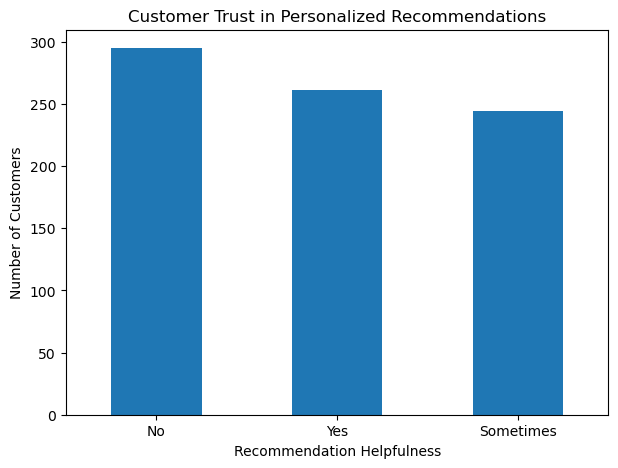

In [363]:
import matplotlib.pyplot as plt

recommendation_counts.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Customer Trust in Personalized Recommendations")
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Frequent shoppers were more likely to trust or engage with personalized recommendations compared to less frequent shoppers, 
#-indicating that recommendation systems may be more effective for regular customers.

In [ ]:
#The majority of customers reported that personalized recommendations were helpful.
#A smaller proportion of customers reported recommendations as sometimes helpful.
#Customers who found recommendations helpful tended to report higher shopping satisfaction.

In [ ]:
#Suggest actionable insights for improving Snapdeal’s recommendation system.
#Suggestions:-
#Use customers' browsing history, purchase history, and preferred product categories to generate more personalized recommendations.
#Remove irrelevant or outdated product suggestions.
#Display review summaries to help customers make informed decisions.
#Provide personalized discounts, coupons, or reminders for abandoned carts.
#Offer introductory deals and popular products to occasional or new shoppers.
#Use Customer Feedback to Improve Recommendations.
#Incentivize customers to leave detailed and verified product reviews regularly.


The analysis indicates that customers are more satisfied when recommendations are relevant, trustworthy, and aligned with their shopping preferences. By improving personalization, leveraging reliable reviews, targeting at-risk customers, and continuously monitoring recommendation performance, Snapdeal can enhance the customer experience, increase customer loyalty, reduce cart abandonment, and drive higher sales.

In [ ]:
#Task 5: Visualization and Reporting (10 Marks)
#● Create attractive visualizations (bar charts, heatmaps, pie charts) for:
#○ Purchase categories
#○ Browsing frequency distribution
#○ Satisfaction levels
#○ Correlation between recommendation usefulness and satisfaction
#● Summarize findings in a clear and visually appealing report format.

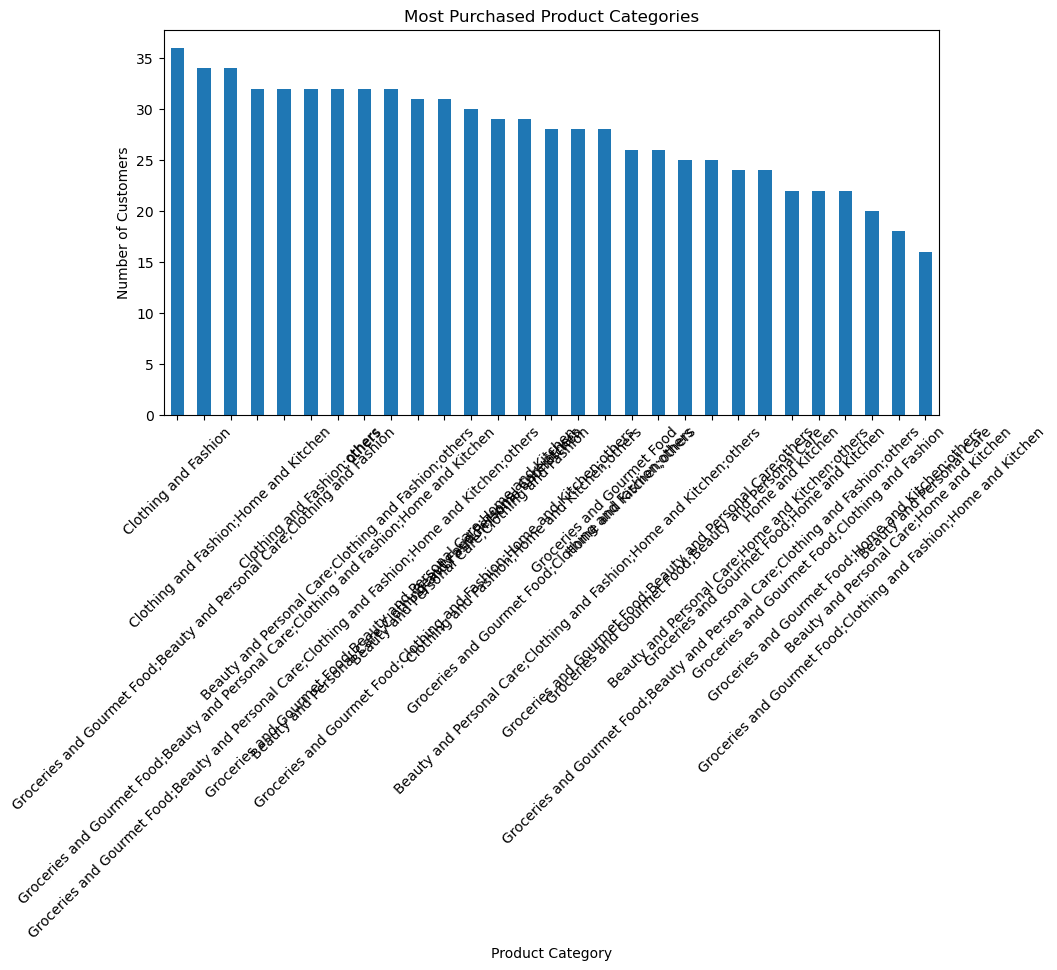

In [392]:
#Purchase categories.
import matplotlib.pyplot as plt

purchase_category = df["Purchase_Categories"].value_counts()

plt.figure(figsize=(10,5))
purchase_category.plot(kind="bar")

plt.title("Most Purchased Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

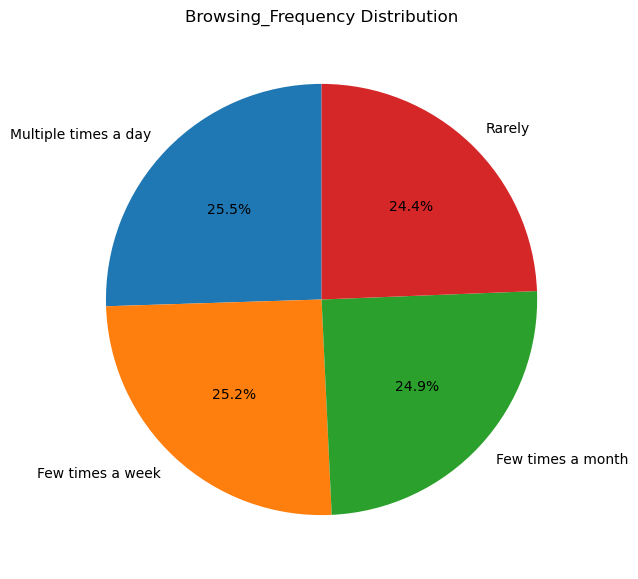

In [403]:
plt.figure(figsize=(7,7))

df["Browsing_Frequency"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90)

plt.title("Browsing_Frequency Distribution")
plt.ylabel("")
plt.show()

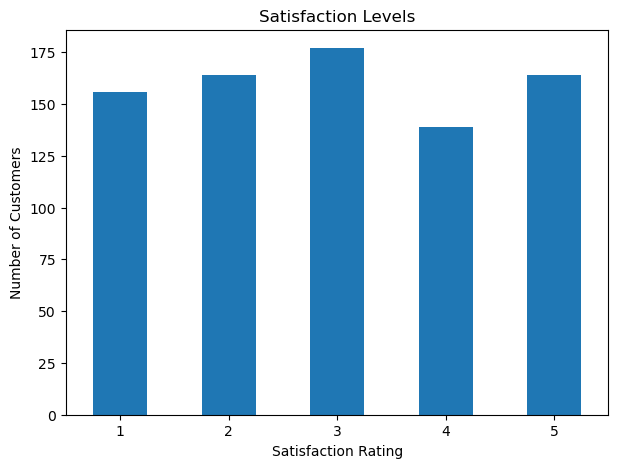

In [401]:
satisfaction = df["Shopping_Satisfaction"].value_counts().sort_index()

plt.figure(figsize=(7,5))

satisfaction.plot(kind="bar")

plt.title("Satisfaction Levels")
plt.xlabel("Satisfaction Rating")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

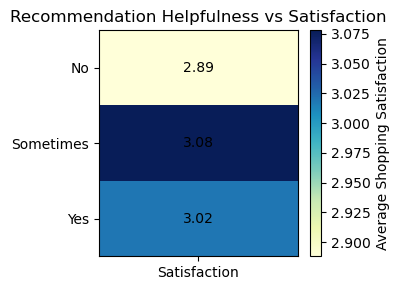

In [415]:
import matplotlib.pyplot as plt

heatmap_data = (
    df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"]
      .mean()
      .to_frame()
)

plt.figure(figsize=(4, 3))

plt.imshow(heatmap_data, cmap="YlGnBu", aspect="auto")

plt.colorbar(label="Average Shopping Satisfaction")

plt.xticks([0], ["Satisfaction"])
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.title("Recommendation Helpfulness vs Satisfaction")

# Display values in the heatmap
for i in range(len(heatmap_data.index)):
    plt.text(0, i, f"{heatmap_data.iloc[i, 0]:.2f}",
             ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [ ]:
#Summarize findings in a clear and visually appealing report format.

In [ ]:
#The majority of customers purchasing the products once a month or a few times in a month, indicating moderate shopping activity.
#Electronics and Fashion emerged among the most frequently purchased product categories, showing strong customer demand.
#Most customers reported moderate to high shopping satisfaction, suggesting a generally positive shopping experience.
#Customers who found the personalized recommendations helpful, tended to have higher satisfaction levels.
#The correlation analysis showed a positive relationship between recommendation helpfulness, rating accuracy, and shopping satisfaction. 
#Customers who trusted recommendations and product ratings were generally more satisfied with their purchases.
#Customer segmentation identified Frequent Buyers, Occasional Shoppers, and At-Risk Customers, enabling targeted marketing and retention strategies.

Recommendations:-
Company needs to Improve the recommendations by incorporating customers' browsing and purchase history.
need to Display the more verified reviews and accurate product ratings to strengthen customer trust.
and Provide personalized offers to occasional and at-risk customers to encourage repeat purchases.
and at last Continuously monitor recommendation performance and customer feedback to refine personalization strategies.

Project Video Link:- https://youtu.be/FHVIFFgDS1Q

Project Video Link:- https://youtu.be/FHVIFFgDS1Q